### Preprocessing

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
import seaborn as sns

In [2]:
data = pd.read_csv('~/ML/HCV/NS3_4A_working/NS3_4A_descriptors.csv')
data = data.dropna()

In [3]:
X = data.drop(columns=['Name', 'pIC50'])
y = data['pIC50']
y = y.str.replace(',', '.').astype(float)

categorial_col = [col for col in X.columns if X[col].nunique() == 2 and int(X[col].max())==1]
numeric_col = [col for col in X.columns if not(X[col].nunique() == 2 and int(X[col].max())==1)]
print(len(categorial_col))
print(len(numeric_col))

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_col),
        ('cat', 'passthrough', categorial_col) 
    ])

X_scaled = preprocessor.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=numeric_col + categorial_col)

4773
13194


In [20]:
X_scaled

,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,nAromBond,nAtom,nHeavyAtom,nH,...,APC2D6_S_S,APC2D6_S_Cl,APC2D7_N_Cl,APC2D7_O_S,APC2D8_N_Cl,APC2D9_N_S,APC2D9_N_Cl,APC2D9_S_Cl,APC2D9_S_X,APC2D10_N_Cl
0,-0.396230,0.559986,-0.764214,-3.082742,-2.326065,0.0,0.0,-2.013051,-2.878635,-1.343991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.061909,-1.253057,1.301075,-1.234755,-0.776459,0.0,0.0,-0.555490,-0.704986,-0.421434,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.832840,1.147413,-0.836257,-1.921893,-1.910066,0.0,0.0,-1.804828,-1.791811,-1.651510,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.832840,1.041263,-0.844872,-2.058302,-2.016009,0.0,0.0,-1.888117,-2.009176,-1.651510,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.832840,1.005628,-0.845624,-3.093892,-2.630989,0.0,0.0,-2.387853,-2.769953,-1.959029,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
482,-0.396230,0.113053,-0.513644,-0.076280,-0.313188,0.0,0.0,-0.472200,-0.378938,-0.482938,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
483,0.832840,0.841598,-0.835220,-3.245250,-2.693563,0.0,0.0,-2.387853,-2.878635,-1.897525,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
484,3.290978,-1.020827,0.881079,-0.118174,0.004374,0.0,0.0,0.069180,0.273157,-0.052411,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
485,3.290978,-1.082755,0.988612,-0.295329,-0.042767,0.0,0.0,0.069180,0.273157,-0.052411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### PCA

In [4]:
pca = PCA(n_components=50) 
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_

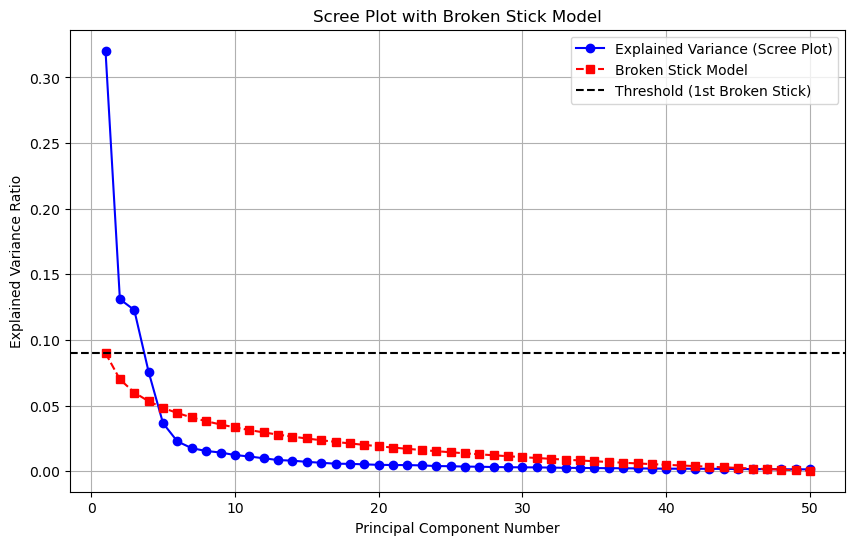

In [6]:
# Broken Stick Model 
# Этот подход используется для определения ожидаемой доли дисперсии, 
# которую каждая главная компонента должна объяснять, если бы дисперсия распределялась случайным образом.
n = len(explained_variance)
broken_stick = np.array([sum(1 / np.arange(i, n + 1)) for i in range(1, n + 1)])
broken_stick /= broken_stick.sum()  # Нормализация

plt.figure(figsize=(10, 6))
plt.plot(range(1, n + 1), explained_variance, marker='o', label='Explained Variance (Scree Plot)', color='blue')
plt.plot(range(1, n + 1), broken_stick, marker='s', linestyle='dashed', color='red', label='Broken Stick Model')
plt.axhline(y=broken_stick[0], color='black', linestyle='--', label="Threshold (1st Broken Stick)")

plt.xlabel("Principal Component Number")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot with Broken Stick Model")
plt.legend()

plt.grid(True)
plt.savefig('Plots/Scree Plot with Broken Stick Model')
plt.show()

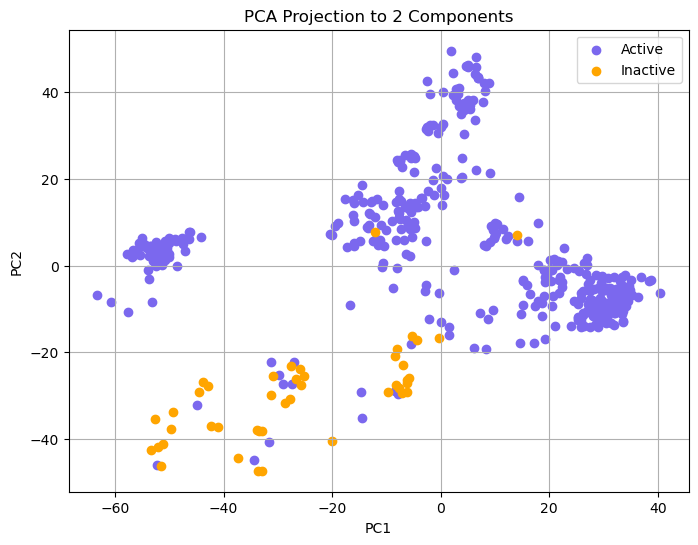

In [7]:
activity = [1 if val>=5 else 0 for val in y]

pca = PCA(n_components=2)
df_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca['Activity'] = activity
# df_pca['pIC50'] = y

plt.figure(figsize=(8, 6))

# Активные - синие крестики
plt.scatter(df_pca[df_pca['Activity'] == 1]['PC1'], df_pca[df_pca['Activity'] == 1]['PC2'],
            color='#7B68EE', marker='o', label='Active')

# Класс 1 - красные кружки
plt.scatter(df_pca[df_pca['Activity'] == 0]['PC1'], df_pca[df_pca['Activity'] == 0]['PC2'],
            color='orange', marker='o', label='Inactive')

# for i in range(len(df_pca)):
#     plt.annotate(df_pca['pIC50'].iloc[i], (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
#                  textcoords="offset points", xytext=(0,5), ha='center', fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection to 2 Components')
plt.legend()
plt.grid(True)
plt.savefig('Plots/PCA projection')
plt.show()

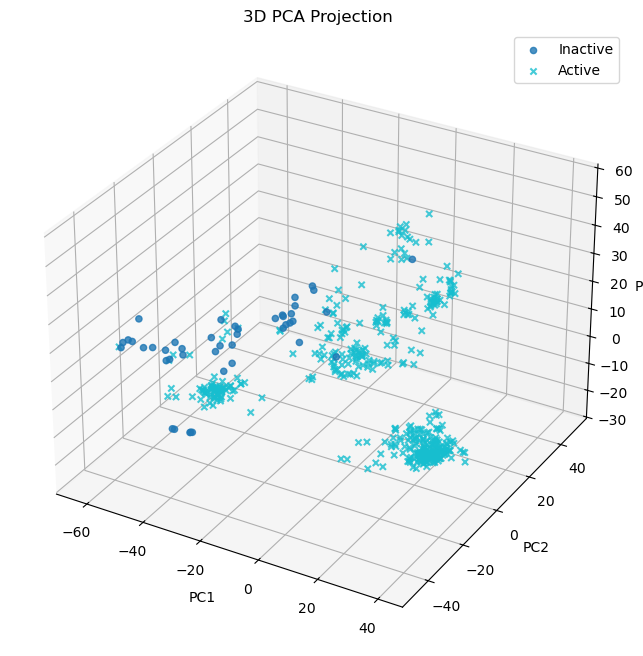

In [65]:
from mpl_toolkits.mplot3d import Axes3D

# Применение PCA с 3 компонентами
pca = PCA(n_components=3)
df_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['Activity'] = activity

# Создание 3D-графика
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Разные цвета и маркеры для классов (может быть больше 0 и 1)
# unique_classes = df_pca['Activity'].unique()
# colors = plt.cm.get_cmap('tab10', len(unique_classes))  # Генерируем цвета динамически
# markers = ['o', 'x', 's', 'D', 'v', '^']  # Возможные маркеры

# Нанесение точек на график
for idx, cls in enumerate(unique_classes):
    subset = df_pca[df_pca['Activity'] == cls]
    label = 'Active' if cls==1 else 'Inactive'
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               color=colors(idx), marker=markers[idx % len(markers)],
               label=label, alpha=0.8)

# Подписи осей
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection')

ax.legend()
plt.show()


## Metrics per PCA components

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_pca[:, :20], y, test_size=0.8, random_state=18)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr
import os

def metrics(method, y_test, y_pred):
    """
    Outputs classification metrics
    """
    #config_path = os.path.join(os.path.dirname(__file__), "../config.yaml")
    #with open(config_path) as f:
    #    config = yaml.safe_load(f)
    
    corr, p_value = pearsonr(y_test, y_pred)
    # print(f'{method}. Classification metrics:\n')
    # print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    # print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
    # print(f"R²: {r2_score(y_test, y_pred)}")
    # print(f"Pearson correlation coefficient: {corr}, p-value: {p_value}\n")
    
    return corr, mean_squared_error(y_test, y_pred)
    

In [81]:
from sklearn.svm import SVR

def support_vector_regression(X_train, X_test, y_train, y_test):
    
    svr = SVR()

    # Parameters for selection
    param_grid = {
        'kernel': ['linear'],
        'C': [0.01, 0.1],  # Уменьшите C
        'gamma': [0.0001, 0.001],  # Уменьшите gamma
        'epsilon': [0.01, 0.1]
    }
    
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18)
    # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    #print(f"Best parametrs: {grid_search.best_params_} \n")
    #print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    #print("Test metrics")
    pcc_test, mse_test = metrics("Support vector regression", y_test, y_pred)
    
    #print('_______________________________________________________________')
    #print("Train metrics")
    pcc_train, mse_train = metrics("Support vector regression", y_train, grid_search.predict(X_train))
    
    return pcc_test, pcc_train, mse_test, mse_train
    


In [65]:
support_vector_regression(X_train, X_test, y_train, y_test)

(np.float64(0.2381454125385159),
 np.float64(0.24412164053774874),
 1.5383777010599249,
 1.4971966438548292)

In [82]:
total_train_pcc = []
total_test_pcc = []
total_mse_train = []
total_mse_test = []
my_range = range(1, 101, 5)
pca = PCA(n_components=100) 
X_pca = pca.fit_transform(X_scaled)

for i in my_range:
    X_train, X_test, y_train, y_test = train_test_split(X_pca[:, :i], y, test_size=0.8, random_state=18)
    pcc_test, pcc_train, mse_test, mse_train = support_vector_regression(X_train, X_test, y_train, y_test)
    total_train_pcc.append(pcc_train)
    total_test_pcc.append(pcc_test)
    total_mse_train.append(mse_train)
    total_mse_test.append(mse_test)
    

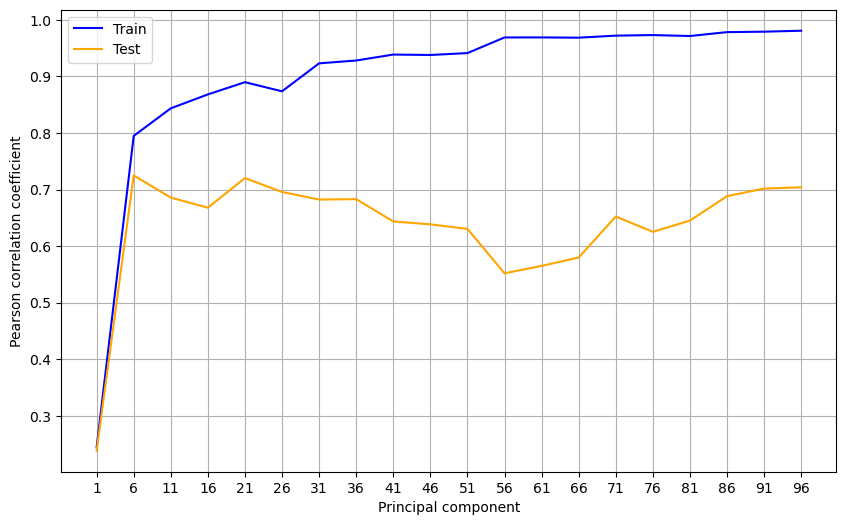

In [83]:
plt.figure(figsize=(10, 6))
plt.plot(my_range, total_train_pcc, color='blue', label='Train')
plt.plot(my_range, total_test_pcc, color='orange', label='Test')
plt.xlabel('Principal component')
plt.ylabel('Pearson correlation coefficient')
plt.xticks(my_range)
plt.grid()
plt.legend()
plt.show()

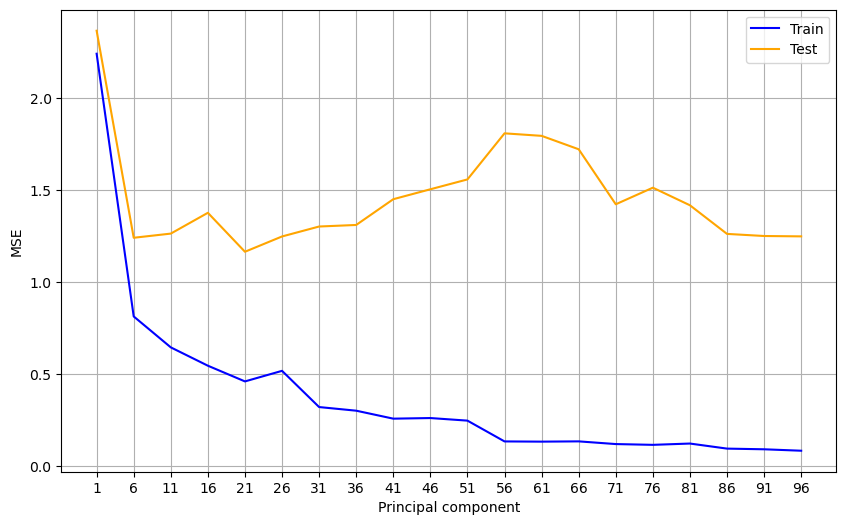

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(my_range, total_mse_train, color='blue', label='Train')
plt.plot(my_range, total_mse_test, color='orange', label='Test')
plt.xlabel('Principal component')
plt.ylabel('MSE')
plt.xticks(my_range)
plt.grid()
plt.legend()
plt.show()

## Clustering

In [11]:
from sklearn.cluster import KMeans

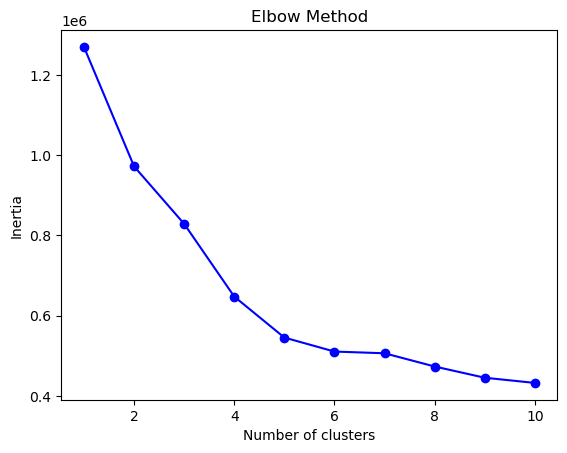

In [114]:
# Кластеризация с помощью K-means

# Выбор оптимального числа кластеров 
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Визуализация метода "локтя"
plt.plot(range(1, 11), inertia, marker='o', color='blue')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Инерция измеряет, насколько плотно точки внутри кластеров расположены относительно центроидов

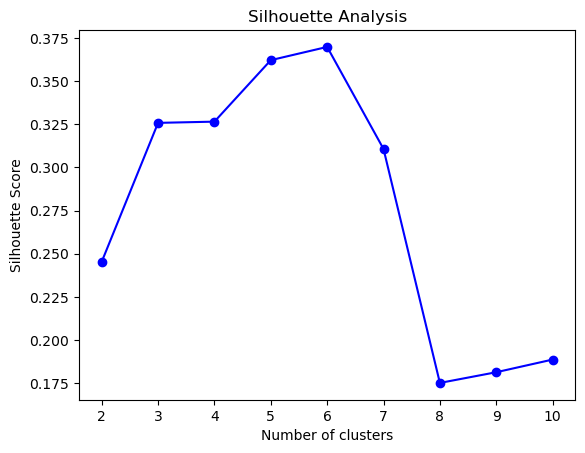

In [115]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o', color='blue')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

Силуэтный анализ оценивает качество кластеризации, измеряя, насколько хорошо каждый объект соответствует своему кластеру по сравнению с другими кластерами. Силуэтный коэффициент варьируется от -1 до 1:
- Значение близкое к 1 указывает на хорошую кластеризацию.
- Значение близкое к 0 указывает на перекрытие кластеров.
- Отрицательное значение указывает на то, что объект, возможно, попал в неправильный кластер.

### K-means with k=5

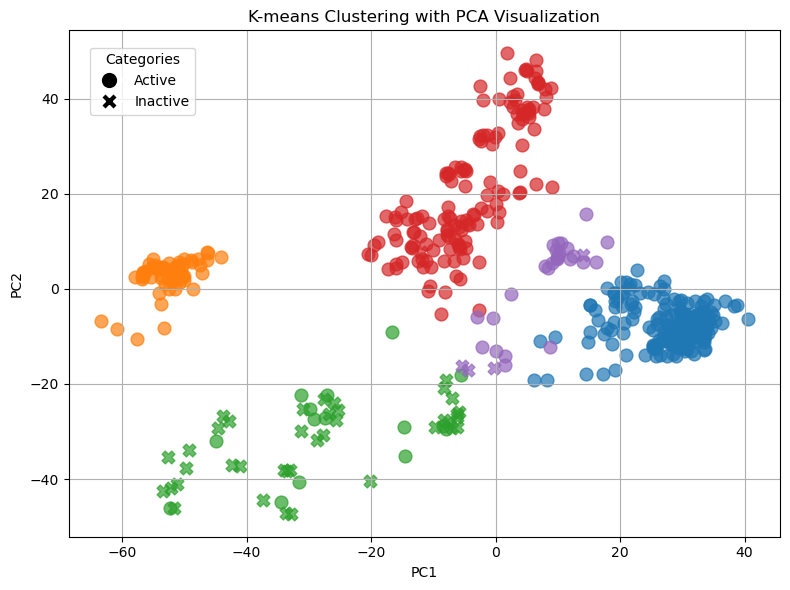

In [12]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент для визуализации
X_pca = pca.fit_transform(X_scaled)

activity = np.array(["Active" if val>=5 else "Inactive" for val in y])
markers = {'Active': 'o', 'Inactive': 'X'}  # Круг, крест
colors = plt.cm.tab10 

plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    for category, marker in markers.items():
        # Фильтруем точки по кластеру и категории
        mask = (labels == cluster) & (activity == category)
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            marker=marker,
            color=colors(cluster),
            s=85,  # Размер точек
            alpha=0.7
        )
        
category_legend = [plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='black', markersize=12) 
                  for marker in markers.values()]
category_labels = list(markers.keys())

plt.legend(category_legend, category_labels, title="Categories", loc='lower left', bbox_to_anchor=(0.02, 0.82))
    
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering with PCA Visualization')
plt.tight_layout()
plt.grid(True)
plt.show()

### t-SNE

In [8]:
from sklearn.manifold import TSNE

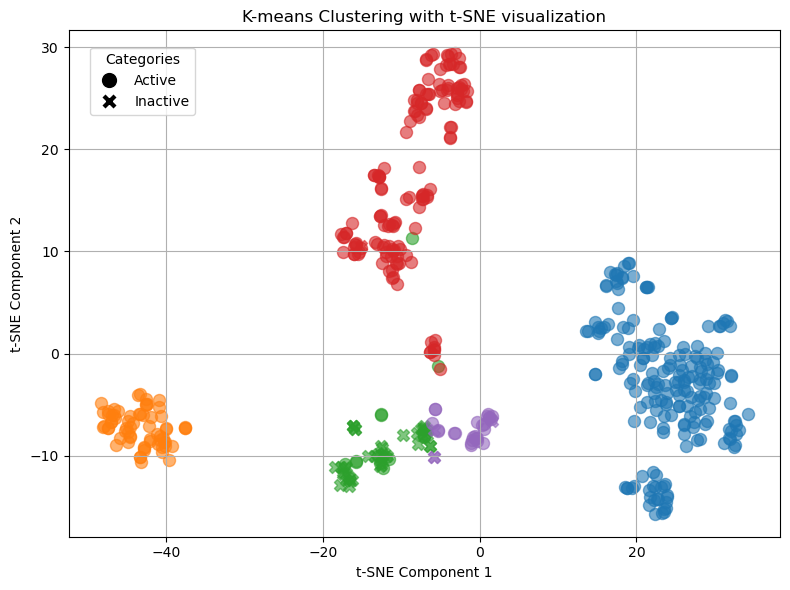

In [13]:
tsne = TSNE(n_components=2, random_state=42) 
X_tsne = tsne.fit_transform(X_scaled)

activity = np.array(["Active" if val>=5 else "Inactive" for val in y])
markers = {'Active': 'o', 'Inactive': 'X'}
colors = plt.cm.tab10 

plt.figure(figsize=(8, 6))
for cluster in range(n_clusters):
    for category, marker in markers.items():
        mask = (labels == cluster) & (activity == category)
        plt.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            marker=marker,
            color=colors(cluster),
            s=75,  # Размер точек
            alpha=0.6
        )
    
    
category_legend = [plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor='black', markersize=12) 
                  for marker in markers.values()]
category_labels = list(markers.keys())

plt.legend(category_legend, category_labels, title="Categories", loc='lower left', bbox_to_anchor=(0.02, 0.82))
    
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('K-means Clustering with t-SNE visualization')
plt.tight_layout()
plt.grid(True)
plt.savefig('Plots/k-means with t-SNE visualization')
plt.show()

## Training on 3 components

In [91]:
from sklearn.metrics import make_scorer

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X_pca[:, :3], y, test_size=0.8, random_state=18)

In [93]:
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * (error ** 2)
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.0)

In [86]:
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from scipy.stats import pearsonr
import os

def metrics(method, y_test, y_pred):
    """
    Outputs classification metrics
    """
    #config_path = os.path.join(os.path.dirname(__file__), "../config.yaml")
    #with open(config_path) as f:
    #    config = yaml.safe_load(f)
    
    corr, p_value = pearsonr(y_test, y_pred)
    print(f'{method}. Classification metrics:\n')
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")
    print(f"R²: {r2_score(y_test, y_pred)}")
    print(f"Pearson correlation coefficient: {corr}, p-value: {p_value}\n")

In [107]:
from sklearn.svm import SVR

def support_vector_regression(X_train, X_test, y_train, y_test):
    
    svr = SVR()

    # Parameters for selection
    param_grid = {
        'kernel': ['rbf', 'linear'],
        'C': [0.0001, 0.001],  # Regularization parameter
        'gamma': [0.0001, 0.001],  # Core coefficient
        'epsilon': [0.01, 0.1]  
    }
    
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18)
    # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        scoring=huber_scorer,  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print(f"Best parametrs: {grid_search.best_params_} \n")
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    metrics("Support vector regression", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    metrics("Support vector regression", y_train, grid_search.predict(X_train))
    
support_vector_regression(X_train, X_test, y_train, y_test)

Best parametrs: {'C': 0.001, 'epsilon': 0.1, 'gamma': 0.0001, 'kernel': 'linear'} 

_______________________________________________________________
Test metrics
Support vector regression. Classification metrics:

MAE: 0.7819459350593833
RMSE: 1.1003647995388064
R²: 0.45262174222280405
Pearson correlation coefficient: 0.7111574320293024, p-value: 2.4028303579894934e-61

_______________________________________________________________
Train metrics
Support vector regression. Classification metrics:

MAE: 0.717253128095395
RMSE: 0.9472087321718765
R²: 0.5870035028514444
Pearson correlation coefficient: 0.7668793837132123, p-value: 5.327657773567853e-20



In [70]:
from sklearn.ensemble import RandomForestRegressor

def random_forest_regression(X_train, X_test, y_train, y_test):
    rf = RandomForestRegressor(random_state=18)

    param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],  
    'min_samples_split': [5, 10],  
    'min_samples_leaf': [3, 5]  
    }

    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)
    #print(f"Best parameters: {grid_search.best_params_} \n")
    y_pred = grid_search.predict(X_test)

    #print("Test metrics")
    pcc_test, rmse_test = metrics("Random Forest Regression", y_test, y_pred)
    #print('_______________________________________________________________')
    #print("Train metrics")
    pcc_train, rmse_train = metrics("Random Forest Regression", y_train, grid_search.predict(X_train))
    
    return pcc_test, pcc_train, rmse_test, rmse_train

random_forest_regression(X_train, X_test, y_train, y_test)

In [48]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, ShuffleSplit

def xgboost_regression(X_train, X_test, y_train, y_test):
    # Модель XGBoost
    xgb = XGBRegressor(random_state=18)

    # Параметры для подбора
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],  # Ограничьте глубину
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0],  # Регуляризация через subsample
        'colsample_bytree': [0.8, 1.0]  # Регуляризация через colsample
    }

    # Кросс-валидация
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=18)
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1,
    )

    # Обучение
    grid_search.fit(X_train, y_train)

    # Лучшие параметры
    print(f"Best parameters: {grid_search.best_params_} \n")
    print('_______________________________________________________________')

    # Предсказание
    y_pred = grid_search.predict(X_test)

    # Оценка модели
    print("Test metrics")
    metrics("XGBoost Regression", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    metrics("XGBoost Regression", y_train, grid_search.predict(X_train))
    
xgboost_regression(X_train, X_test, y_train, y_test)

In [68]:
from sklearn.neural_network import MLPRegressor

def MLP_regressor(X_train, X_test, y_train, y_test):
    
    #mlp = MLPRegressor()
    mlp = MLPRegressor(early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=100,
    max_iter=50000)
    
    param_grid = {
    'hidden_layer_sizes': [(2,), (5,)],
    #'activation': ['logistic', 'tanh','relu'],
    #'solver': ['sgd', 'adam'],
    'learning_rate': ['adaptive'],
    'alpha': [0.1, 0.5, 1],
    'learning_rate_init': [0.00001, 0.00005],
    'max_iter': [50000]
}
    
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=18)
     # Cross-validation with GridSearchCV
    grid_search = GridSearchCV(
        estimator=mlp,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # Optimization metric
        cv=cv,  # Number of folds
        n_jobs=-1,  # Use all CPU cores
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Best parametrs
    print("Best parametrs:", grid_search.best_params_)
    print('_______________________________________________________________')

    # Prediction
    y_pred = grid_search.predict(X_test)

    # Model evaluation
    print("Test metrics")
    metrics("Multi-layer Perceptron regressor", y_test, y_pred)
    
    print('_______________________________________________________________')
    print("Train metrics")
    metrics("Multi-layer Perceptron regressor", y_train, grid_search.predict(X_train))
    
MLP_regressor(X_train, X_test, y_train, y_test)

## Столбчатая диаграмма MSE

In [7]:
mse_DT = pd.read_csv('mse_DT.csv', index_col=0) 
mse_GB = pd.read_csv('mse_GB.csv', index_col=0)
mse_RF = pd.read_csv('mse_RF.csv', index_col=0)

full_mse = pd.concat([mse_DT, mse_GB, mse_RF], axis=1)
full_mse['Model'] = ["SVR", "kNN", "MLP"]

print(full_mse)

     DT_train   DT_test  GB_train   GB_test  RF_train   RF_test Model
SVR  0.882064  0.926672  0.653282  0.845342  0.754311  0.892321   SVR
kNN  0.388832  0.479324  0.369934  0.482908  0.366201  0.463748   kNN
MLP  0.470317  0.852801  0.675084  0.929795  0.630497  0.840746   MLP


In [9]:
# Преобразование данных в длинный формат
df_melted = full_mse.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Разделение столбца Metric на Method (DT, GB, RF) и Type (train, test)
df_melted[['Method', 'Type']] = df_melted['Metric'].str.split('_', expand=True)

print(df_melted)

   Model    Metric     Score Method   Type
0    SVR  DT_train  0.882064     DT  train
1    kNN  DT_train  0.388832     DT  train
2    MLP  DT_train  0.470317     DT  train
3    SVR   DT_test  0.926672     DT   test
4    kNN   DT_test  0.479324     DT   test
5    MLP   DT_test  0.852801     DT   test
6    SVR  GB_train  0.653282     GB  train
7    kNN  GB_train  0.369934     GB  train
8    MLP  GB_train  0.675084     GB  train
9    SVR   GB_test  0.845342     GB   test
10   kNN   GB_test  0.482908     GB   test
11   MLP   GB_test  0.929795     GB   test
12   SVR  RF_train  0.754311     RF  train
13   kNN  RF_train  0.366201     RF  train
14   MLP  RF_train  0.630497     RF  train
15   SVR   RF_test  0.892321     RF   test
16   kNN   RF_test  0.463748     RF   test
17   MLP   RF_test  0.840746     RF   test


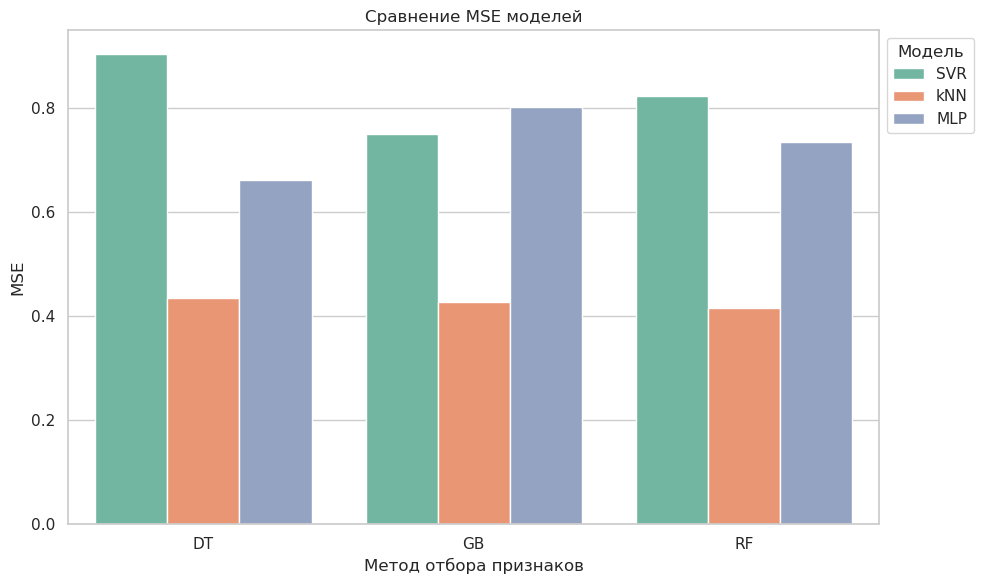

In [17]:
# Настройка стиля
sns.set(style="whitegrid")

# Создание группированной столбчатой диаграммы
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Method', 
    y='Score', 
    hue='Model', 
    data=df_melted, 
    palette='Set2', 
    errorbar=None, 
    dodge=True
)

# Добавление подписей
plt.title('Сравнение MSE моделей')
plt.xlabel('Метод отбора признаков')
plt.ylabel('MSE')
plt.legend(title='Модель', bbox_to_anchor=(1, 1), loc='upper left')

# Отображение диаграммы
plt.tight_layout()
plt.show()

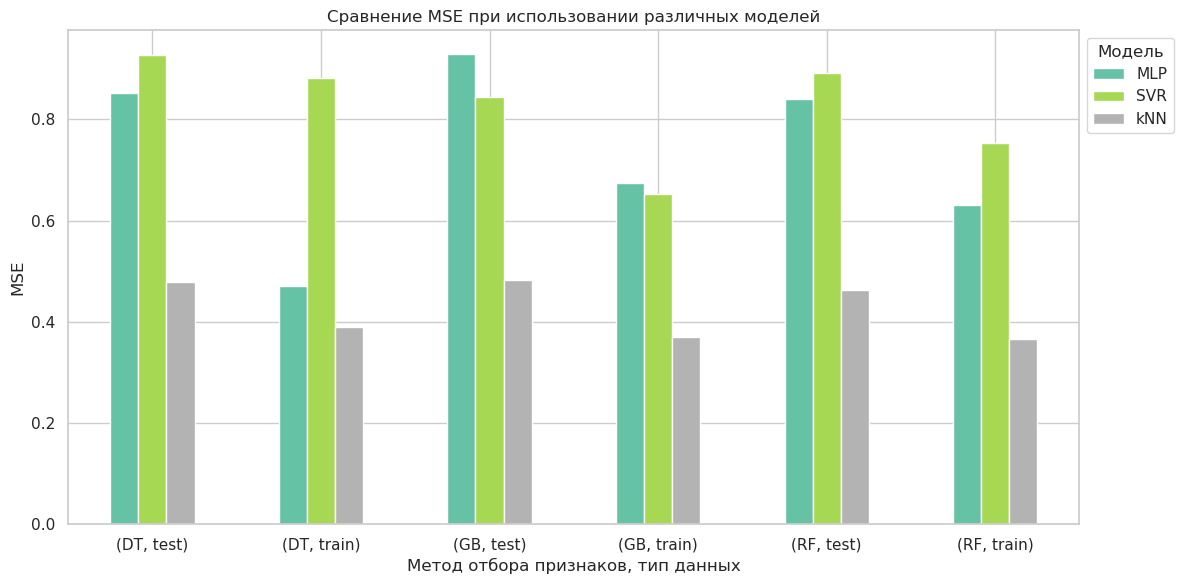

In [21]:
# Преобразование данных
df_pivot = df_melted.pivot_table(index=['Method', 'Type'], columns='Model', values='Score')

# Построение диаграммы
df_pivot.plot(kind='bar', figsize=(12, 6), colormap='Set2')

# Добавление подписей
plt.title('Сравнение MSE при использовании различных моделей')
plt.xlabel('Метод отбора признаков, тип данных')
plt.ylabel('MSE')
plt.legend(title='Модель', bbox_to_anchor=(1, 1), loc='upper left')

plt.xticks(rotation=0) 

# Отображение диаграммы
plt.tight_layout()
plt.show()

In [22]:
df_pivot

Model              MLP       SVR       kNN
Method Type                               
DT     test   0.852801  0.926672  0.479324
       train  0.470317  0.882064  0.388832
GB     test   0.929795  0.845342  0.482908
       train  0.675084  0.653282  0.369934
RF     test   0.840746  0.892321  0.463748
       train  0.630497  0.754311  0.366201

## Столбчатая диаграмма R^2

In [15]:
R2_DT = pd.read_csv('R2/R2_DT.csv', index_col=0) 
R2_GB = pd.read_csv('R2/R2_GB.csv', index_col=0)
R2_RF = pd.read_csv('R2/R2_RF.csv', index_col=0)

full_R2 = pd.concat([R2_DT, R2_GB, R2_RF], axis=1)
full_R2['Model'] = ["SVR", "kNN", "MLP"]

print(full_R2)

     DT_train   DT_test  GB_train   GB_test  RF_train   RF_test Model
SVR  0.589453  0.658314  0.695937  0.688302  0.648914  0.670980   SVR
kNN  0.819022  0.823262  0.827818  0.821941  0.829556  0.829005   kNN
MLP  0.715682  0.665422  0.685790  0.657163  0.607998  0.608830   MLP


In [16]:
# Преобразование данных в длинный формат
R2_melted = full_R2.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

# Разделение столбца Metric на Method (DT, GB, RF) и Type (train, test)
R2_melted[['Method', 'Type']] = R2_melted['Metric'].str.split('_', expand=True)

print(R2_melted)

   Model    Metric     Score Method   Type
0    SVR  DT_train  0.589453     DT  train
1    kNN  DT_train  0.819022     DT  train
2    MLP  DT_train  0.715682     DT  train
3    SVR   DT_test  0.658314     DT   test
4    kNN   DT_test  0.823262     DT   test
5    MLP   DT_test  0.665422     DT   test
6    SVR  GB_train  0.695937     GB  train
7    kNN  GB_train  0.827818     GB  train
8    MLP  GB_train  0.685790     GB  train
9    SVR   GB_test  0.688302     GB   test
10   kNN   GB_test  0.821941     GB   test
11   MLP   GB_test  0.657163     GB   test
12   SVR  RF_train  0.648914     RF  train
13   kNN  RF_train  0.829556     RF  train
14   MLP  RF_train  0.607998     RF  train
15   SVR   RF_test  0.670980     RF   test
16   kNN   RF_test  0.829005     RF   test
17   MLP   RF_test  0.608830     RF   test


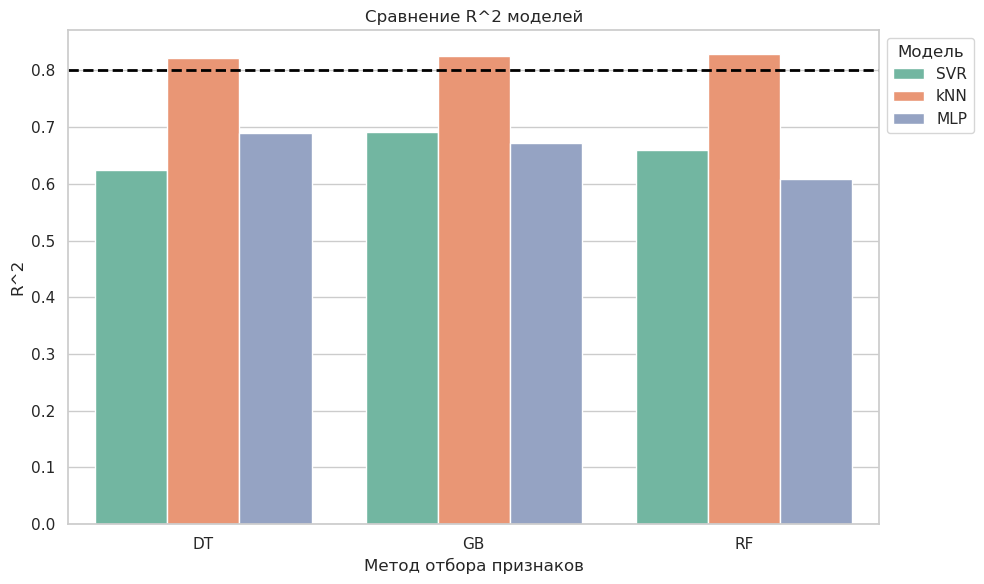

In [31]:
# Настройка стиля
sns.set(style="whitegrid")

# Создание группированной столбчатой диаграммы
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Method', 
    y='Score', 
    hue='Model', 
    data=R2_melted, 
    palette='Set2', 
    errorbar=None, 
    dodge=True
)

# Добавление подписей
plt.title('Сравнение R^2 моделей')
plt.xlabel('Метод отбора признаков')
plt.ylabel('R^2')
plt.legend(title='Модель', bbox_to_anchor=(1, 1), loc='upper left')
plt.axhline(y=0.8, color='black', linestyle='--', linewidth=2, label='Сильная корреляция')

# Отображение диаграммы
plt.tight_layout()
plt.show()

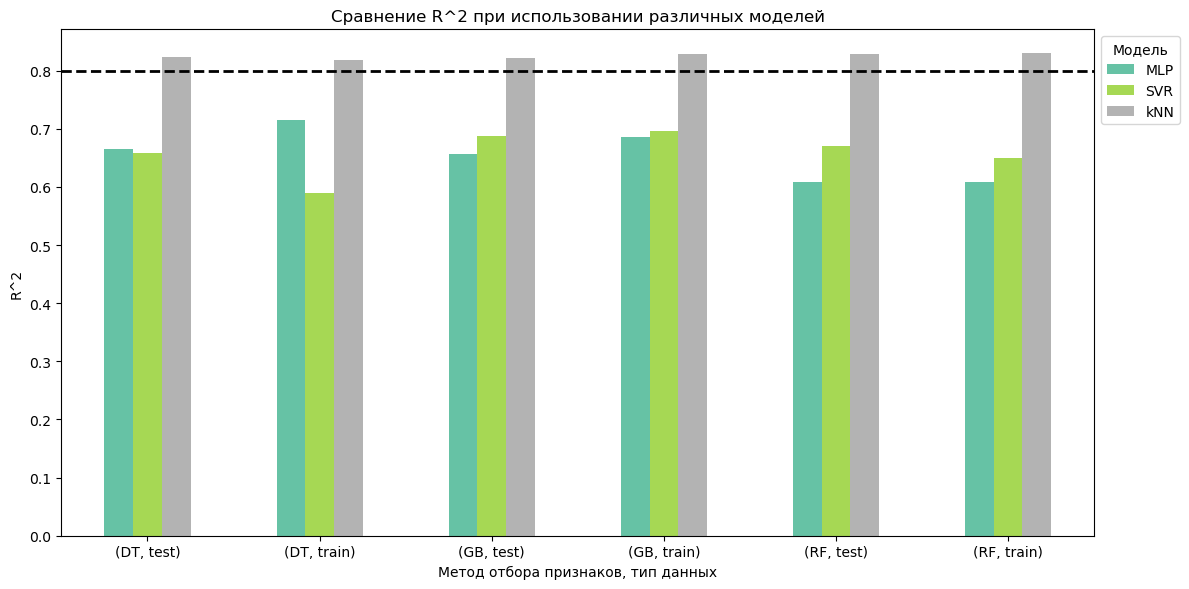

In [17]:
# Преобразование данных
R2_pivot = R2_melted.pivot_table(index=['Method', 'Type'], columns='Model', values='Score')

# Построение диаграммы
R2_pivot.plot(kind='bar', figsize=(12, 6), colormap='Set2')

# Добавление подписей
plt.title('Сравнение R^2 при использовании различных моделей')
plt.xlabel('Метод отбора признаков, тип данных')
plt.ylabel('R^2')
plt.axhline(y=0.8, color='black', linestyle='--', linewidth=2)
plt.legend(title='Модель', bbox_to_anchor=(1, 1), loc='upper left')

plt.xticks(rotation=0) 

# Отображение диаграммы
plt.tight_layout()
plt.savefig('Plots/R2 comparison')
plt.show()